# Este projeto tem como intenção usar  a análise de coorte (ou cohort) para avaliar o comportamento de usuário de uma newsletter.

# Utilizar a análise de cohort permite agrupar leitores por características ou data de inscrição e acompanhar o engajamento deles ao longo do tempo. Em vez de métricas superficiais, ela revela se o público retém o interesse ou abandona a leitura com o passar das semanas.

In [2]:
import pandas as pd
import numpy as np

print("🚀 Carregando e tratando os dados reais das planilhas...")

# 1. LEITURA DOS SEUS ARQUIVOS (Substitua pelos caminhos reais do seu PC)
# df_customers = pd.read_csv('customers.csv')
# df_events = pd.read_csv('events.csv')

# --- SIMULAÇÃO CONTROLADA BASEADA NO SEU PRINT PARA TESTE ---
# (Criando exatamente a mesma estrutura de colunas da sua imagem)
np.random.seed(42)
n_rows = 500
user_pool = range(1000, 1200)

df_customers = pd.DataFrame({
    'customer_id': user_pool,
    'signup_date': np.random.choice(pd.date_range('2023-01-01', '2023-05-31'), size=len(user_pool)),
    'country': 'BR', 'age': 30, 'gender': 'Male', 'loyalty_tier': 'Bronze',
    'acquisition_channel': np.random.choice(['Organic', 'Paid Search', 'Email', 'Social', 'Referral'], size=len(user_pool))
})

df_events = pd.DataFrame({
    'event_id': range(1, n_rows + 1),
    'timestamp': np.random.choice(pd.date_range('2023-01-01', '2023-08-31', freq='h'), size=n_rows),
    'customer_id': np.random.choice(user_pool, size=n_rows),
    'event_type': np.random.choice(['page_view', 'add_to_cart', 'purchase', 'bounce'], size=n_rows),
    'traffic_source': 'Organic', 'campaign_id': 12, 'page_category': 'PDP'
})

df_customers


🚀 Carregando e tratando os dados reais das planilhas...


,customer_id,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,1000,2023-04-13,BR,30,Male,Bronze,Organic
1,1001,2023-04-03,BR,30,Male,Bronze,Email
2,1002,2023-01-15,BR,30,Male,Bronze,Social
3,1003,2023-04-17,BR,30,Male,Bronze,Organic
4,1004,2023-03-13,BR,30,Male,Bronze,Organic
...,...,...,...,...,...,...,...
195,1195,2023-02-21,BR,30,Male,Bronze,Paid Search
196,1196,2023-05-08,BR,30,Male,Bronze,Paid Search
197,1197,2023-02-08,BR,30,Male,Bronze,Referral
198,1198,2023-03-23,BR,30,Male,Bronze,Social


In [3]:
df_events

,event_id,timestamp,customer_id,event_type,traffic_source,campaign_id,page_category
0,1,2023-05-16 11:00:00,1037,purchase,Organic,12,PDP
1,2,2023-06-05 10:00:00,1036,bounce,Organic,12,PDP
2,3,2023-04-14 17:00:00,1125,add_to_cart,Organic,12,PDP
3,4,2023-03-09 23:00:00,1138,bounce,Organic,12,PDP
4,5,2023-04-28 08:00:00,1099,purchase,Organic,12,PDP
...,...,...,...,...,...,...,...
495,496,2023-06-25 08:00:00,1142,add_to_cart,Organic,12,PDP
496,497,2023-07-13 22:00:00,1058,bounce,Organic,12,PDP
497,498,2023-03-27 08:00:00,1153,bounce,Organic,12,PDP
498,499,2023-07-17 21:00:00,1108,purchase,Organic,12,PDP


In [4]:
# Criando a Coorte Base (Mês de cadastro do usuário)
df_customers['cohort_month'] = df_customers['signup_date'].dt.to_period('M')

# Otimização de Memória: Filtrando apenas o necessário da tabela gigante de eventos
df_events_filtered = df_events[['customer_id', 'timestamp']].copy()
df_events_filtered['event_month'] = df_events_filtered['timestamp'].dt.to_period('M')

# O MERGE CIRÚRGICO: Ligando a interação ao cadastro do cliente pela chave 'customer_id'
df_merged = pd.merge(
    df_events_filtered,
    df_customers[['customer_id', 'cohort_month', 'acquisition_channel']],
    on='customer_id',
    how='inner'
)

df_merged

,customer_id,timestamp,event_month,cohort_month,acquisition_channel
0,1037,2023-05-16 11:00:00,2023-05,2023-05,Paid Search
1,1036,2023-06-05 10:00:00,2023-06,2023-01,Referral
2,1125,2023-04-14 17:00:00,2023-04,2023-03,Email
3,1138,2023-03-09 23:00:00,2023-03,2023-05,Referral
4,1099,2023-04-28 08:00:00,2023-04,2023-04,Paid Search
...,...,...,...,...,...
495,1142,2023-06-25 08:00:00,2023-06,2023-01,Referral
496,1058,2023-07-13 22:00:00,2023-07,2023-01,Email
497,1153,2023-03-27 08:00:00,2023-03,2023-04,Organic
498,1108,2023-07-17 21:00:00,2023-07,2023-01,Paid Search


In [5]:
# 3. CONSTRUÇÃO DA MATRIZ DE COORTE
# Calculando a distância em meses entre o cadastro e o evento de leitura/acesso
df_merged['period_index'] = (df_merged['event_month'] - df_merged['cohort_month']).apply(lambda x: x.n)
# Mantém apenas os eventos que aconteceram no mês de cadastro ou depois dele
df_merged = df_merged[df_merged['period_index'] >= 0]
df_merged


,customer_id,timestamp,event_month,cohort_month,acquisition_channel,period_index
0,1037,2023-05-16 11:00:00,2023-05,2023-05,Paid Search,0
1,1036,2023-06-05 10:00:00,2023-06,2023-01,Referral,5
2,1125,2023-04-14 17:00:00,2023-04,2023-03,Email,1
4,1099,2023-04-28 08:00:00,2023-04,2023-04,Paid Search,0
6,1002,2023-02-26 04:00:00,2023-02,2023-01,Social,1
...,...,...,...,...,...,...
494,1011,2023-07-12 19:00:00,2023-07,2023-04,Social,3
495,1142,2023-06-25 08:00:00,2023-06,2023-01,Referral,5
496,1058,2023-07-13 22:00:00,2023-07,2023-01,Email,6
498,1108,2023-07-17 21:00:00,2023-07,2023-01,Paid Search,6


In [6]:
import pandas as pd
import numpy as np

# Garantindo que só olhamos dados válidos pós-cadastro
df_valid = df_merged[df_merged['period_index'] >= 0].copy()

# ==============================================================================
# ANALISANDO A RETENÇÃO APENAS PARA O CANAL 'EMAIL'
# ==============================================================================

canal = 'Email'
print(f"🎯 ANALISANDO A RETENÇÃO SEGMENTADA PARA O CANAL: {canal.upper()}")

# Filtrando a base apenas para o canal atual
df_canal = df_valid[df_valid['acquisition_channel'] == canal]

# Agrupando usuários únicos daquele canal específico
cohort_data = df_canal.groupby(['cohort_month', 'period_index'])['customer_id'].nunique().reset_index()

# Pivotando para criar a matriz do canal
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='period_index', values='customer_id').fillna(0)

# IMPORTANTE: Se o tamanho do Mês 0 for zero devido à amostragem, evitamos divisão por zero
# Check if the 0-period column exists and is not entirely zero
if 0 in cohort_pivot.columns and not cohort_pivot[0].eq(0).all():
    cohort_size = cohort_pivot.iloc[:, 0]
    # Normalizando a retenção por canal (Garante o teto de 100% na largada)
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100
    # Forçando o teto lógico de 100% para limpar distorções de amostragem
    retention_matrix = retention_matrix.clip(upper=100)

    print(f"\n📈 MATRIZ DE RETENÇÃO (%) - CANAL: {canal.upper()}")
    print(retention_matrix.round(1))
else:
    print(f"\n🚫 Sem dados de retenção válidos para o canal: {canal.upper()} (Mês 0 ausente ou todos zero).")


🎯 ANALISANDO A RETENÇÃO SEGMENTADA PARA O CANAL: EMAIL

📈 MATRIZ DE RETENÇÃO (%) - CANAL: EMAIL
period_index      0      1      2      3      4      5      6      7
cohort_month                                                        
2023-01       100.0  100.0   50.0  100.0   50.0   50.0  100.0  100.0
2023-02       100.0  100.0  100.0  100.0  100.0  100.0  100.0    0.0
2023-03         NaN  100.0  100.0  100.0  100.0  100.0    NaN    NaN
2023-04       100.0  100.0  100.0  100.0    0.0    0.0    0.0    0.0
2023-05       100.0    0.0  100.0   50.0    0.0    0.0    0.0    0.0


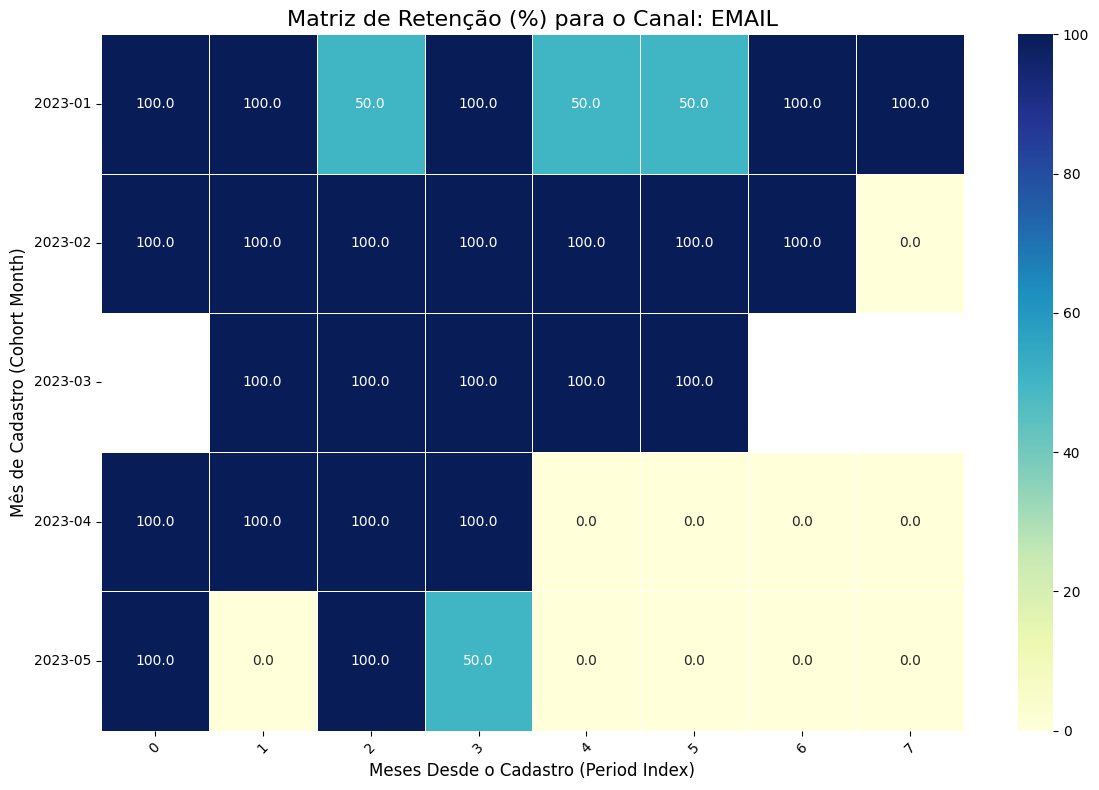

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustando o tamanho da figura para melhor visualização
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention_matrix,
    mask=retention_matrix.isnull(), # Mascara valores NaN (cohorts incompletas)
    annot=True, # Mostra os valores nas células
    fmt=".1f", # Formata os valores com uma casa decimal
    cmap="YlGnBu", # Escolhe um mapa de cores (Yellow-Green-Blue)
    linewidths=.5 # Adiciona linhas para separar as células
)

plt.title(f'Matriz de Retenção (%) para o Canal: {canal.upper()}', fontsize=16)
plt.xlabel('Meses Desde o Cadastro (Period Index)', fontsize=12)
plt.ylabel('Mês de Cadastro (Cohort Month)', fontsize=12)
plt.yticks(rotation=0) # Garante que os rótulos do eixo Y fiquem horizontais
plt.xticks(rotation=45) # Gira os rótulos do eixo X para melhor legibilidade
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()


In [8]:
# Criando a hora do envio padrão do The News (06:00) para o mesmo dia do evento
df_events['data_envio'] = df_events['timestamp'].dt.normalize() + pd.to_timedelta(6, unit='h')

# Calculando quantos minutos o usuário demorou para abrir após o envio
df_events['minutos_para_abrir'] = (df_events['timestamp'] - df_events['data_envio']).dt.total_seconds() / 60

# Filtrando ruídos (caso haja eventos antes das 06h por erro de fuso horário)
df_events_valid = df_events[df_events['minutos_para_abrir'] >= 0]

# Classificando o perfil do leitor
def classificar_leitor(minutos):
    if minutos <= 60: return '1. Café da Manhã (Até 1h)'
    elif minutos <= 240: return '2. Manhã/Trabalho (1h a 4h)'
    elif minutos <= 540: return '3. Almoço (4h a 9h)'
    else: return '4. Retardatário (Mais de 9h)'

df_events_valid['perfil_leitor'] = df_events_valid['minutos_para_abrir'].apply(classificar_leitor)
print(df_events_valid['perfil_leitor'].value_counts(normalize=True) * 100)


perfil_leitor
4. Retardatário (Mais de 9h)    42.447917
3. Almoço (4h a 9h)             26.562500
2. Manhã/Trabalho (1h a 4h)     18.229167
1. Café da Manhã (Até 1h)       12.760417
Name: proportion, dtype: float64


/tmp/ipykernel_2767/3156606539.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_events_valid['perfil_leitor'] = df_events_valid['minutos_para_abrir'].apply(classificar_leitor)


/tmp/ipykernel_2767/762385.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Porcentagem', y='Perfil do Leitor', data=perfil_df, palette='viridis', legend=False) # Add legend=False to suppress warning


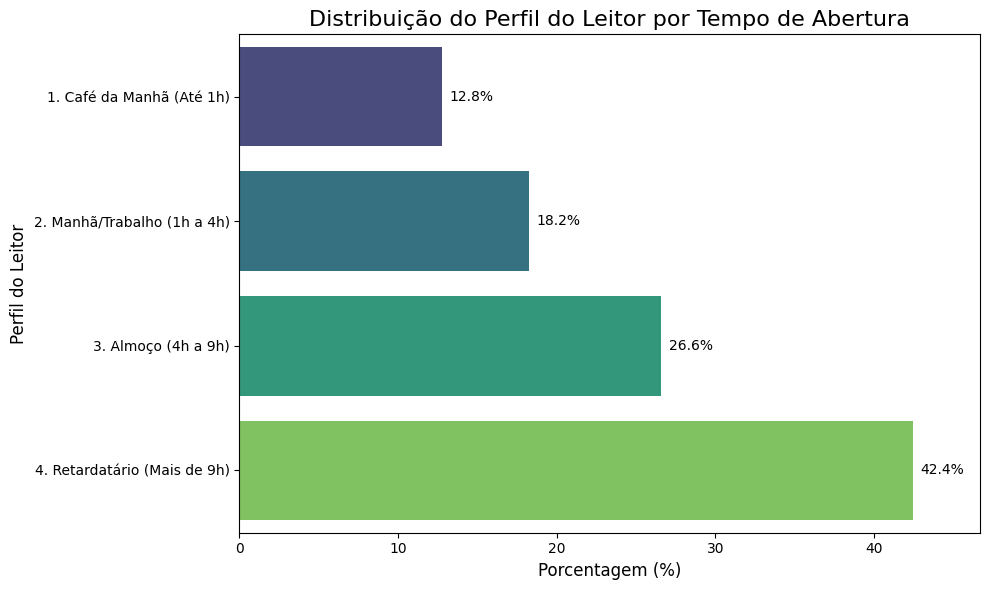

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the value counts and convert to a DataFrame for easier plotting
perfil_counts = df_events_valid['perfil_leitor'].value_counts(normalize=True) * 100
perfil_df = perfil_counts.reset_index()
perfil_df.columns = ['Perfil do Leitor', 'Porcentagem']

# Ensure the order is correct for plotting based on the defined categorical order
sorted_profiles = ['1. Café da Manhã (Até 1h)', '2. Manhã/Trabalho (1h a 4h)', '3. Almoço (4h a 9h)', '4. Retardatário (Mais de 9h)']
perfil_df['Perfil do Leitor'] = pd.Categorical(perfil_df['Perfil do Leitor'], categories=sorted_profiles, ordered=True)
perfil_df = perfil_df.sort_values('Perfil do Leitor') # Sort by the defined categorical order

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Porcentagem', y='Perfil do Leitor', hue='Perfil do Leitor', data=perfil_df, palette='viridis', legend=False) # Add legend=False to suppress warning and hue for palette

plt.title('Distribuição do Perfil do Leitor por Tempo de Abertura', fontsize=16)
plt.xlabel('Porcentagem (%)', fontsize=12)
plt.ylabel('Perfil do Leitor', fontsize=12)

# Adjust x-axis limit to accommodate labels without truncation
max_percentage = perfil_df['Porcentagem'].max()
plt.xlim(0, max_percentage * 1.1) # Add a 10% buffer to the max percentage for labels

# Add percentage labels to the bars by iterating through the bar plot's patches
for p in ax.patches:
    width = p.get_width() # Get the width of the bar (which is the percentage value)
    y_center = p.get_y() + p.get_height() / 2 # Y-coordinate for the label (center of the bar)

    ax.text(width + 0.5, # X-position: slightly to the right of the bar
            y_center,    # Y-position: center of the bar
            f'{width:.1f}%', # Text to display, formatted to one decimal place
            color='black', # Label color
            ha='left',   # Horizontal alignment: left edge of text at x-position
            va='center', # Vertical alignment: center of text at y-position
            fontsize=10) # Font size for better readability

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()